# 01 - Data Ingestion & EDA

Questa fase focalizza sul caricamento e sulla pulizia del Data Lake finanziario.

**Step:**
1. Caricamento dati locali (CSV Borsa Italiana: anagrafica + storico prezzi)
2. Data Consistency Check (ISIN comuni, overlap temporale)
3. Filtraggio universo (plain vanilla gov bonds europei)
4. Caricamento dati macro da API eterogenee (FRED, pandasdmx, eurostat)
5. Exploratory Data Analysis (EDA)

## 1.1 - Import

In [40]:
import pandas as pd
import numpy as np
import re
import pandas_datareader.data as web
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


## 1.2 - Caricamento Dati Locali (Micro-dati da SimpleToolsForInvestors)

In [41]:
# Percorsi dei file CSV locali
file_path_storico = "./dataset/Archivio con lo storico prezzi dei titoli in formato CSV(Ultimo aggiornamento 07-05-2026).csv"
file_path_anagrafica = "./dataset/Obbligazioni quotate su Borsa Italiana(Ultimo aggiornamento 07-05-2026).csv"

# Caricamento storico prezzi
df_storico = pd.read_csv(file_path_storico,
                        sep=';',
                        decimal=',',
                        parse_dates=['referencedate', 'endvaluedate'],
                        dayfirst=True)

# Caricamento anagrafica obbligazioni
try:
    df_anagrafica = pd.read_csv(file_path_anagrafica, sep=';', decimal=',')
    print(f"✓ Anagrafica caricata: {df_anagrafica.shape[0]} righe")
except Exception as e:
    print(f"✗ Errore nel caricamento dell'anagrafica: {e}")
    df_anagrafica = None

print(f"✓ Storico caricato: {df_storico.shape[0]} righe")

✓ Anagrafica caricata: 3629 righe
✓ Storico caricato: 827771 righe


In [42]:
# Pulizia base: rimozione spazi, uniformità nomi colonne
if df_anagrafica is not None:
    df_anagrafica.columns = df_anagrafica.columns.str.strip().str.lower()
    df_storico.columns = df_storico.columns.str.strip().str.lower()

# Cast di isin a stringa
if df_anagrafica is not None:
    if 'isincode' in df_anagrafica.columns:
        df_anagrafica['isincode'] = df_anagrafica['isincode'].astype(str)
    if 'isincode' in df_storico.columns:
        df_storico['isincode'] = df_storico['isincode'].astype(str)

print("\n--- Dataset Dimensions ---")
print(f"Storico prezzi: {df_storico.shape}")
if df_anagrafica is not None:
    print(f"Anagrafica: {df_anagrafica.shape}")


--- Dataset Dimensions ---
Storico prezzi: (827771, 10)
Anagrafica: (3629, 13)


In [43]:
# Preview dei dati
print("\n--- Preview Storico Prezzi ---")
display(df_storico.head())

print("\n--- Preview Anagrafica ---")
if df_anagrafica is not None:
    display(df_anagrafica.head())


--- Preview Storico Prezzi ---


,isincode,marketcode,referencedate,endvaluedate,pricetype,pricevalue,volume,mintoday,maxtoday,unnamed: 9
0,AT0000383864,MOT,2023-01-02,2023-01-03,RP,115.22,0,0.00,0.00,NaN
1,AT0000383864,MOT,2023-01-03,2023-01-04,RP,115.59,0,0.00,0.00,NaN
2,AT0000383864,MOT,2023-01-04,2023-01-05,LP,116.35,4000,116.35,116.38,NaN
3,AT0000383864,MOT,2023-01-05,2023-01-06,LP,116.50,5000,116.50,116.50,NaN
4,AT0000383864,MOT,2023-01-06,2023-01-09,LP,116.60,2000,116.60,116.60,NaN



--- Preview Anagrafica ---


,firstdate,marketcode,segmentcode,isincode,description,currencycode,minimumlot,status,issuedate,issueprice,redemptiondate,redemptionprice,unnamed: 12
0,07/05/2026,EUROTLX,EUROTLX,XS3318840223,Lottomaticag Fx 4.625% Apr32 Call Eur,EUR,100000.0,NaN,NaN,NaN,30/04/2032,NaN,NaN
1,07/05/2026,EUROTLX,EUROTLX,XS2433136194,Israel Fx 0.625% Jan32 Eur,EUR,1000.0,NaN,NaN,NaN,18/01/2032,NaN,NaN
2,07/05/2026,EUROTLX,EUROTLX,XS1936101291,Israel Fx 2.5% Jan49 Eur,EUR,1000.0,NaN,NaN,NaN,16/01/2049,NaN,NaN
3,07/05/2026,EUROTLX,EUROTLX,XS1936100483,Israel Fx 1.5% Jan29 Eur,EUR,1000.0,NaN,NaN,NaN,16/01/2029,NaN,NaN
4,07/05/2026,EUROTLX,EUROTLX,US46513JB593,Israel Fx 4.5% Apr20 Usd,USD,200000.0,NaN,NaN,NaN,03/04/2120,NaN,NaN


In [44]:
# Rimozione colonne non necessarie (segmentcode, status, unnamed e endvaluedate)
if df_anagrafica is not None:
    cols_to_drop = [col for col in df_anagrafica.columns if 'unnamed' in col or 'status' in col or 'segmentcode' in col]
    df_anagrafica.drop(columns=cols_to_drop, inplace=True)

if df_storico is not None:
    cols_to_drop_storico = [col for col in df_storico.columns if 'unnamed' in col or 'endvaluedate' in col]
    df_storico.drop(columns=cols_to_drop_storico, inplace=True)
    
print("\n--- Preview Anagrafica ---")
if df_anagrafica is not None:
    display(df_anagrafica.head())

print("\n--- Preview Storico ---")
if df_storico is not None:
    display(df_storico.head())



--- Preview Anagrafica ---


,firstdate,marketcode,isincode,description,currencycode,minimumlot,issuedate,issueprice,redemptiondate,redemptionprice
0,07/05/2026,EUROTLX,XS3318840223,Lottomaticag Fx 4.625% Apr32 Call Eur,EUR,100000.0,NaN,NaN,30/04/2032,NaN
1,07/05/2026,EUROTLX,XS2433136194,Israel Fx 0.625% Jan32 Eur,EUR,1000.0,NaN,NaN,18/01/2032,NaN
2,07/05/2026,EUROTLX,XS1936101291,Israel Fx 2.5% Jan49 Eur,EUR,1000.0,NaN,NaN,16/01/2049,NaN
3,07/05/2026,EUROTLX,XS1936100483,Israel Fx 1.5% Jan29 Eur,EUR,1000.0,NaN,NaN,16/01/2029,NaN
4,07/05/2026,EUROTLX,US46513JB593,Israel Fx 4.5% Apr20 Usd,USD,200000.0,NaN,NaN,03/04/2120,NaN



--- Preview Storico ---


,isincode,marketcode,referencedate,pricetype,pricevalue,volume,mintoday,maxtoday
0,AT0000383864,MOT,2023-01-02,RP,115.22,0,0.00,0.00
1,AT0000383864,MOT,2023-01-03,RP,115.59,0,0.00,0.00
2,AT0000383864,MOT,2023-01-04,LP,116.35,4000,116.35,116.38
3,AT0000383864,MOT,2023-01-05,LP,116.50,5000,116.50,116.50
4,AT0000383864,MOT,2023-01-06,LP,116.60,2000,116.60,116.60


## 1.3 - Data Consistency Check (ISIN Comuni)

In [45]:
# Estraiamo gli ISIN unici sotto forma di set
if df_anagrafica is not None and df_storico is not None:
    isins_in_anagrafica = set(df_anagrafica['isincode'].unique())
    isins_in_storico = set(df_storico['isincode'].unique())

# Analisi dell'intersezione
common_isins = isins_in_anagrafica.intersection(isins_in_storico)
only_in_anagrafica = isins_in_anagrafica - isins_in_storico
only_in_storico = isins_in_storico - isins_in_anagrafica

print("--- REPORT DATA CONSISTENCY ---")
print(f"Totale ISIN unici in Anagrafica: {len(isins_in_anagrafica)}")
print(f"Totale ISIN unici in Storico:    {len(isins_in_storico)}")
print(f"ISIN COMUNI (Utilizzabili):      {len(common_isins)}")
print(f"-----")
print(f"ISIN scartati (Solo in Anagrafica, no prezzi): {len(only_in_anagrafica)}")
print(f"ISIN scartati (Solo in Storico, no anagrafica): {len(only_in_storico)}")

--- REPORT DATA CONSISTENCY ---
Totale ISIN unici in Anagrafica: 3504
Totale ISIN unici in Storico:    1309
ISIN COMUNI (Utilizzabili):      1309
-----
ISIN scartati (Solo in Anagrafica, no prezzi): 2195
ISIN scartati (Solo in Storico, no anagrafica): 0


In [46]:
# Filtraggio: teniamo solo gli ISIN comuni
if df_anagrafica is not None and df_storico is not None:
    df_anagrafica_filtrato = df_anagrafica[df_anagrafica['isincode'].isin(common_isins)].copy()
    df_storico_filtrato = df_storico[df_storico['isincode'].isin(common_isins)].copy()

print(f"✓ Dataset filtrato per ISIN comuni")
print(f"  Anagrafica: {df_anagrafica_filtrato.shape[0]} righe")
print(f"  Storico: {df_storico_filtrato.shape[0]} righe")

✓ Dataset filtrato per ISIN comuni
  Anagrafica: 1335 righe
  Storico: 827771 righe


## 1.4 - Filtraggio Avanzato dell'Universo di Trading

Selezioniamo solo obbligazioni governative europee **Plain Vanilla** (tasso fisso, nessuna struttura esotica).

In [47]:
print(f"ISIN totali PRIMA del filtraggio avanzato: {df_anagrafica_filtrato['isincode'].nunique()}")

# 1. Filtro per Obbligazioni Governative Europee
european_gov_codes = ['IT', 'DE', 'FR', 'ES', 'PT', 'AT', 'BE', 'NL', 'FI', 'IE', 'GR']

is_european_gov = (df_anagrafica_filtrato['isincode'].str.startswith(tuple(european_gov_codes))) & \
                  (df_anagrafica_filtrato['description'].str.contains('GOV|Btp|Schatz|OAT|Bonos|Obligaciones|Bund|BOT|CTZ|Bubill|Zc', case=False, na=False))

df_anagrafica_gov = df_anagrafica_filtrato[is_european_gov].copy()
print(f"✓ ISIN rimasti dopo filtro 'EU Government': {df_anagrafica_gov['isincode'].nunique()}")

# 2. Escludiamo Obbligazioni "Esotiche" (cedola variabile, inflation-linked, etc.)
parole_chiave_escluse = ['Futura', 'Italia', 'Inflazione', 'Indicizzato', 'Inflation', 'Valore', 'Btpi', 'Linker', 'Piu']
pattern_esclusione = '|'.join(parole_chiave_escluse)

is_exotic = df_anagrafica_gov['description'].str.contains(pattern_esclusione, case=False, na=False)
df_anagrafica_clean = df_anagrafica_gov[~is_exotic].copy()
print(f"✓ ISIN rimasti dopo esclusione 'Esotici': {df_anagrafica_clean['isincode'].nunique()}")

# Lista finale di ISIN "puri"
final_clean_isins = set(df_anagrafica_clean['isincode'].unique())

print(f"\n--- RISULTATO FINALE FILTRAGGIO ---")
print(f"Numero di obbligazioni 'Plain Vanilla' per il modello: {len(final_clean_isins)}")

# Filtrare anche lo storico con la nuova lista di ISIN puliti
df_storico_clean = df_storico_filtrato[df_storico_filtrato['isincode'].isin(final_clean_isins)].copy()
print(f"Dimensioni Storico finale: {df_storico_clean.shape}")

display(df_storico_clean)

ISIN totali PRIMA del filtraggio avanzato: 1309
✓ ISIN rimasti dopo filtro 'EU Government': 337
✓ ISIN rimasti dopo esclusione 'Esotici': 305

--- RISULTATO FINALE FILTRAGGIO ---
Numero di obbligazioni 'Plain Vanilla' per il modello: 305
Dimensioni Storico finale: (189510, 8)


,isincode,marketcode,referencedate,pricetype,pricevalue,volume,mintoday,maxtoday
54004,DE0001030708,MOT,2023-01-02,RP,83.82,0,0.00,0.00
54005,DE0001030708,MOT,2023-01-03,RP,84.07,0,0.00,0.00
54006,DE0001030708,MOT,2023-01-04,RP,84.62,0,0.00,0.00
54007,DE0001030708,MOT,2023-01-05,RP,84.37,0,0.00,0.00
54008,DE0001030708,MOT,2023-01-06,RP,85.00,0,0.00,0.00
...,...,...,...,...,...,...,...,...
429806,IT0005706285,MOT,2026-05-07,LP,100.62,2074000,100.49,100.92
429811,IT0005707614,MOT,2026-05-04,LP,99.25,2002000,99.25,99.58
429812,IT0005707614,MOT,2026-05-05,LP,99.42,692000,99.27,99.44
429813,IT0005707614,MOT,2026-05-06,LP,100.17,2315000,99.78,100.31


## 1.5 - Analisi della Profondità Storica

In [48]:
# Time span globale del dataset
min_date = df_storico_filtrato['referencedate'].min()
max_date = df_storico_filtrato['referencedate'].max()

print(f"--- TIME SPAN DEL DATASET STORICO ---")
print(f"Data più vecchia: {min_date.strftime('%d/%m/%Y')}")
print(f"Data più recente: {max_date.strftime('%d/%m/%Y')}")
print(f"Profondità totale: {(max_date - min_date).days} giorni")

# Quanti dati ha davvero ogni obbligazione?
history_lengths = df_storico_filtrato.groupby('isincode')['referencedate'].count()

print(f"\n--- ANALISI STORICO PER SINGOLO TITOLO ---")
print(f"Giorni di storico MEDIO per bond: {history_lengths.mean():.0f}")
print(f"Giorni di storico MEDIANO: {history_lengths.median():.0f}")
print(f"Titoli con meno di 6 mesi (< 130 giorni): {(history_lengths < 130).sum()}")
print(f"Titoli con più di 1 anno (> 250 giorni): {(history_lengths > 250).sum()}")

--- TIME SPAN DEL DATASET STORICO ---
Data più vecchia: 02/01/2023
Data più recente: 07/05/2026
Profondità totale: 1221 giorni

--- ANALISI STORICO PER SINGOLO TITOLO ---
Giorni di storico MEDIO per bond: 632
Giorni di storico MEDIANO: 833
Titoli con meno di 6 mesi (< 130 giorni): 120
Titoli con più di 1 anno (> 250 giorni): 1109


## 1.6 - Caricamento Dati Macroeconomici (API Eterogenee: FRED, Yahoo Finance)

In [49]:
import os
from dotenv import load_dotenv
load_dotenv()
import warnings
warnings.filterwarnings('ignore')
import datetime
import pandas as pd
from fredapi import Fred

# ============================================================================
# CONFIGURAZIONE FRED API KEY
# ============================================================================
# OPZIONE 1: Usa variabile d'ambiente (CONSIGLIATO - più sicuro)
# Impostala prima di eseguire il notebook:
#   Linux/Mac:  export FRED_API_KEY="tua_api_key_qui"
#   Windows:    set FRED_API_KEY=tua_api_key_qui
#   O in Python:
fred_api_key = os.environ.get('FRED_API_KEY')

# OPZIONE 2: Se non è impostata come variabile d'ambiente, inseriscila qui
if not fred_api_key:
    fred_api_key = None  # Sostituisci con "tua_api_key_qui" se necessario

if fred_api_key:
    fred = Fred(api_key=fred_api_key)
    print(f"✓ FRED API Key configurata (primi 10 caratteri: {fred_api_key[:10]}...")
else:
    fred = Fred()
    print("⚠ FRED API Key NON configurata. I dati pubblici funzioneranno comunque senza rate limits elevati.")


# Date di inizio e fine
start_date = datetime.datetime(2000, 1, 1)
end_date = datetime.datetime(2026, 5, 8)


✓ FRED API Key configurata (primi 10 caratteri: f041051526...


In [50]:
# ============================================================================
# [1/3] FRED Daily (Federal Reserve Economic Data)
# ============================================================================
print("\n[1/3] Scaricamento dati FRED giornalieri...")

fred_daily_tickers = {
    'ECB_Deposit_Rate': 'ECBDFR',              # Tasso Deposit Facility (BCE) - DAILY 99-26
    'ECB_MRO_Rate': 'ECBMRRFR',                # Main Refinancing Operations Rate (BCE) - DAILY 99-26
    'FED_Rate': 'EFFR',                        # Effective Federal Funds Rate (US) - DAILY 00-26
    'VIX': 'VIXCLS'                            # Volatilità implicita S&P 500 ("paura" globale) - DAILY 90-26
}

fred_series = {}
for name, ticker in fred_daily_tickers.items():
    try:
        series = fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
        series.index = pd.to_datetime(series.index)
        fred_series[name] = series.rename(name)
        print(f"✓ Dato '{name}' scaricato con successo. Osservazioni: {series.notna().sum()}")
    except Exception as e:
        print(f"✗ Errore nel download di '{name}': {e}")

if fred_series:
    df_fred_daily = pd.concat(fred_series.values(), axis=1).sort_index()
    print(f"\n✓ FRED caricato: {df_fred_daily.shape[0]} righe x {df_fred_daily.shape[1]} colonne")
    print(df_fred_daily.notna().sum().to_string())
else:
    df_fred_daily = pd.DataFrame()
    print("✗ Nessuna serie FRED scaricata correttamente.")


display(df_fred_daily)


[1/3] Scaricamento dati FRED giornalieri...
✓ Dato 'ECB_Deposit_Rate' scaricato con successo. Osservazioni: 9625
✓ Dato 'ECB_MRO_Rate' scaricato con successo. Osservazioni: 6594
✓ Dato 'FED_Rate' scaricato con successo. Osservazioni: 6490
✓ Dato 'VIX' scaricato con successo. Osservazioni: 6657

✓ FRED caricato: 9625 righe x 4 colonne
ECB_Deposit_Rate    9625
ECB_MRO_Rate        6594
FED_Rate            6490
VIX                 6657


,ECB_Deposit_Rate,ECB_MRO_Rate,FED_Rate,VIX
2000-01-01,2.0,3.00,NaN,NaN
2000-01-02,2.0,3.00,NaN,NaN
2000-01-03,2.0,3.00,NaN,24.21
2000-01-04,2.0,3.00,NaN,27.01
2000-01-05,2.0,3.00,NaN,26.41
...,...,...,...,...
2026-05-04,2.0,2.15,3.64,18.29
2026-05-05,2.0,2.15,3.64,17.38
2026-05-06,2.0,2.15,3.64,17.39
2026-05-07,2.0,2.15,3.63,17.08


In [51]:
# ============================================================================
# [2/3] FRED Monthly (Federal Reserve Economic Data)
# ============================================================================
print("\n[2/3] Scaricamento dati FRED mensili...")

fred_monthly_tickers = {
    'ESI_Index': 'CSCICP02EZM460S',            # Composite Consumer Confidence for Euro Area - MONTHLY 73-26
    'Euribor_3M': 'IR3TIB01EZM156N',           # Euribor 3M - MONTHLY 94-26
    'Euribor_1Y': 'IRLTLT01EZM156N',           # Euribor 1Y - MONTHLY 70-26
    'HICP_Euroarea': 'CP0000EZ19M086NEST'      # Harmonized Index of Consumer Prices for Euro Area - MONTHLY 96-26
}

fred_series = {}
for name, ticker in fred_monthly_tickers.items():
    try:
        series = fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
        series.index = pd.to_datetime(series.index)
        fred_series[name] = series.rename(name)
        print(f"✓ Dato '{name}' scaricato con successo. Osservazioni: {series.notna().sum()}")
    except Exception as e:
        print(f"✗ Errore nel download di '{name}': {e}")

if fred_series:
    df_fred_monthly = pd.concat(fred_series.values(), axis=1).sort_index()
    print(f"\n✓ FRED caricato: {df_fred_monthly.shape[0]} righe x {df_fred_monthly.shape[1]} colonne")
    print(df_fred_monthly.notna().sum().to_string())
else:
    df_fred_monthly = pd.DataFrame()
    print("✗ Nessuna serie FRED scaricata correttamente.")


display(df_fred_monthly)


[2/3] Scaricamento dati FRED mensili...
✓ Dato 'ESI_Index' scaricato con successo. Osservazioni: 313
✓ Dato 'Euribor_3M' scaricato con successo. Osservazioni: 313
✓ Dato 'Euribor_1Y' scaricato con successo. Osservazioni: 313
✓ Dato 'HICP_Euroarea' scaricato con successo. Osservazioni: 316

✓ FRED caricato: 316 righe x 4 colonne
ESI_Index        313
Euribor_3M       313
Euribor_1Y       313
HICP_Euroarea    316


,ESI_Index,Euribor_3M,Euribor_1Y,HICP_Euroarea
2000-01-01,-0.4,3.343143,5.698539,58.17
2000-02-01,-0.7,3.536762,5.663599,58.36
2000-03-01,-0.5,3.747043,5.490629,58.57
2000-04-01,-0.9,3.925278,5.413799,58.62
2000-05-01,-0.5,4.362045,5.515497,58.70
...,...,...,...,...
2025-12-01,-13.2,2.045783,3.244733,100.62
2026-01-01,-12.4,2.027727,3.220984,100.04
2026-02-01,NaN,NaN,NaN,100.70
2026-03-01,NaN,NaN,NaN,101.98


In [52]:
import yfinance as yf
# ============================================================================
# [3/3] Yahoo Finance (VSTOXX, VIX, sentiment di mercato)
# ============================================================================
print("\n[3/3] Scaricamento dati Yahoo Finance...")

yf_tickers = {
    'STOXX50': '^STOXX50E',         # Indice azioni europee
    'XEON': 'XEON.MI',              # EURO SHORT-TERM RATE
    'SEGA': 'SEGA.MI'               # iShares Core Euro Government Bond
}

df_yf: pd.DataFrame = pd.DataFrame()
for name, ticker in yf_tickers.items():
    try:
        data = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if not data.empty:
            df_yf[name] = data['Close']
            print(f"  ✓ {name} ({ticker}): OK - {len(data)} osservazioni")
    except Exception as e:
        print(f"  ✗ {name} ({ticker}): FAILED - {str(e)[:50]}")

if not df_yf.empty:
    idx = pd.to_datetime(df_yf.index, errors="coerce")
    if isinstance(idx, pd.DatetimeIndex):
        if idx.tz is not None:
            idx = idx.tz_localize(None)
        df_yf.index = idx

display(df_yf)


[3/3] Scaricamento dati Yahoo Finance...
  ✓ STOXX50 (^STOXX50E): OK - 4787 osservazioni
  ✓ XEON (XEON.MI): OK - 4656 osservazioni
  ✓ SEGA (SEGA.MI): OK - 3828 osservazioni


,STOXX50,XEON,SEGA
Date,,,
2007-03-30,4181.029785,NaN,NaN
2007-04-02,4189.549805,NaN,NaN
2007-04-03,4246.299805,NaN,NaN
2007-04-04,4261.830078,NaN,NaN
2007-04-05,4271.540039,NaN,NaN
...,...,...,...
2026-04-30,5881.509766,149.031494,108.830002
2026-05-04,5763.609863,149.038895,108.430000
2026-05-05,5869.629883,149.044296,108.669998


## 1.7 - Rendiamo continui i dati

In [53]:
# I dati giornalieri hanno alcune NaN, ma è normale per i giorni festivi e fine settimana.
# Applichiamo il forward fill, visto che è più ragionevole assumere che se manca un dato in un giorno festivo, il valore sia lo stesso dell'ultimo giorno lavorativo precedente
if not df_fred_daily.empty:
    df_fred_daily.ffill(inplace=True)   
    display(df_fred_daily)

,ECB_Deposit_Rate,ECB_MRO_Rate,FED_Rate,VIX
2000-01-01,2.0,3.00,NaN,NaN
2000-01-02,2.0,3.00,NaN,NaN
2000-01-03,2.0,3.00,NaN,24.21
2000-01-04,2.0,3.00,NaN,27.01
2000-01-05,2.0,3.00,NaN,26.41
...,...,...,...,...
2026-05-04,2.0,2.15,3.64,18.29
2026-05-05,2.0,2.15,3.64,17.38
2026-05-06,2.0,2.15,3.64,17.39
2026-05-07,2.0,2.15,3.63,17.08


In [54]:
# Ora rimangono solo i dati che cominciano dopo il 2000-01-01. Per VIX sono solo 2 giorni. 
# Ma il FED_Rate inizia solo dal 2000-07-03, allora assumo che i tassi fossero uguali prima di quella data 

if not df_fred_daily.empty:
    df_fred_daily['FED_Rate'] = df_fred_daily['FED_Rate'].bfill()
    df_fred_daily['VIX'] = df_fred_daily['VIX'].bfill()  # Anche VIX ha pochi dati all'inizio, quindi facciamo bfill per mantenere coerenza
    display(df_fred_daily)

,ECB_Deposit_Rate,ECB_MRO_Rate,FED_Rate,VIX
2000-01-01,2.0,3.00,7.03,24.21
2000-01-02,2.0,3.00,7.03,24.21
2000-01-03,2.0,3.00,7.03,24.21
2000-01-04,2.0,3.00,7.03,27.01
2000-01-05,2.0,3.00,7.03,26.41
...,...,...,...,...
2026-05-04,2.0,2.15,3.64,18.29
2026-05-05,2.0,2.15,3.64,17.38
2026-05-06,2.0,2.15,3.64,17.39
2026-05-07,2.0,2.15,3.63,17.08


In [55]:
# Prevenzione Lookahead Bias: allineamento dati di inflazione al mese precedente
if not df_fred_monthly.empty and 'HICP_Euroarea' in df_fred_monthly.columns:
    df_fred_monthly['HICP_Euroarea'] = df_fred_monthly['HICP_Euroarea'].shift(-1)

# creo indice master giornaliero
master_index = pd.date_range(start=start_date, end=end_date, freq='D')
df_fred_monthly = df_fred_monthly.reindex(master_index)

# Forward fill per dati macroeconomici mensili(non posso usare l'interpolazione, questo causerebbe lookahead bias. Sopratutto nei dati dell'inflazione)
if not df_fred_monthly.empty:
    df_fred_monthly.ffill(inplace=True)
    display(df_fred_monthly)

,ESI_Index,Euribor_3M,Euribor_1Y,HICP_Euroarea
2000-01-01,-0.4,3.343143,5.698539,58.36
2000-01-02,-0.4,3.343143,5.698539,58.36
2000-01-03,-0.4,3.343143,5.698539,58.36
2000-01-04,-0.4,3.343143,5.698539,58.36
2000-01-05,-0.4,3.343143,5.698539,58.36
...,...,...,...,...
2026-05-04,-12.4,2.027727,3.220984,103.02
2026-05-05,-12.4,2.027727,3.220984,103.02
2026-05-06,-12.4,2.027727,3.220984,103.02
2026-05-07,-12.4,2.027727,3.220984,103.02


In [56]:
# Controllo se ho NaN dopo tutti i fill
if not df_fred_daily.empty:
    print("\n--- Controllo NaN dopo fill ---")
    print(df_fred_daily.isna().sum().to_string())

if not df_fred_monthly.empty:
    print("\n--- Controllo NaN dopo fill ---")
    print(df_fred_monthly.isna().sum().to_string())


--- Controllo NaN dopo fill ---
ECB_Deposit_Rate    0
ECB_MRO_Rate        0
FED_Rate            0
VIX                 0

--- Controllo NaN dopo fill ---
ESI_Index        0
Euribor_3M       0
Euribor_1Y       0
HICP_Euroarea    0


In [57]:
# Eseguiamo il merge finale di tutte le fonti (FRED Daily, FRED Monthly, Yahoo Finance) 

# Merge esplicito di tutte le fonti disponibili
frames = []
if not df_fred_daily.empty:
    frames.append(df_fred_daily)
if not df_fred_monthly.empty:
    frames.append(df_fred_monthly)
if not df_yf.empty:
    frames.append(df_yf)
    
if frames:
    df_macro = pd.concat(frames, axis=1).sort_index()
else:
    df_macro = pd.DataFrame()

# Forward-fill dei dati nei giorni festivi e fine settimana (consideriamo che il prezzo rimanga lo stesso)
if not df_macro.empty:
    business_index = pd.bdate_range(start=df_macro.index.min(), end=end_date, freq='D')
    df_macro = df_macro.reindex(business_index).ffill()

# Assicuriamoci che la colonna delle date sia in formato datetime e ordinata
if not df_macro.empty:
    df_macro.index = pd.to_datetime(df_macro.index)
    df_macro.sort_index(inplace=True)

print(f"\n✓ Dataset macro-economico COMPLETO:")
print(f"  Shape: {df_macro.shape}")
print(f"  Colonne: {list(df_macro.columns)}")
print(f"  Time range: {df_macro.index.min().date()} to {df_macro.index.max().date()}")
print(f"  Missing values totali: {df_macro.isna().sum().sum()}")
print("\nMissing per colonna:")
print(df_macro.isna().sum().sort_values(ascending=False).to_string())



✓ Dataset macro-economico COMPLETO:
  Shape: (9625, 11)
  Colonne: ['ECB_Deposit_Rate', 'ECB_MRO_Rate', 'FED_Rate', 'VIX', 'ESI_Index', 'Euribor_3M', 'Euribor_1Y', 'HICP_Euroarea', 'STOXX50', 'XEON', 'SEGA']
  Time range: 2000-01-01 to 2026-05-08
  Missing values totali: 9239

Missing per colonna:
SEGA                3670
XEON                2924
STOXX50             2645
FED_Rate               0
ECB_MRO_Rate           0
ECB_Deposit_Rate       0
VIX                    0
Euribor_1Y             0
Euribor_3M             0
ESI_Index              0
HICP_Euroarea          0


## 1.8 - EDA (Exploratory Data Analysis)

In [58]:
# Statistiche descrittive dell'anagrafica
print("--- STATISTICHE ANAGRAFICA BOND ---")
display(df_anagrafica_clean[['isincode', 'description']].describe())

--- STATISTICHE ANAGRAFICA BOND ---


,isincode,description
count,305,305
unique,305,305
top,IT0005707614,Btp Fx 3.15% Jun31 Eur
freq,1,1


--- STATISTICHE PREZZI ---
count    189510.000000
mean         93.278877
std          15.306737
min          24.160000
25%          86.950000
50%          96.060000
75%         101.470000
max         138.490000
Name: pricevalue, dtype: float64


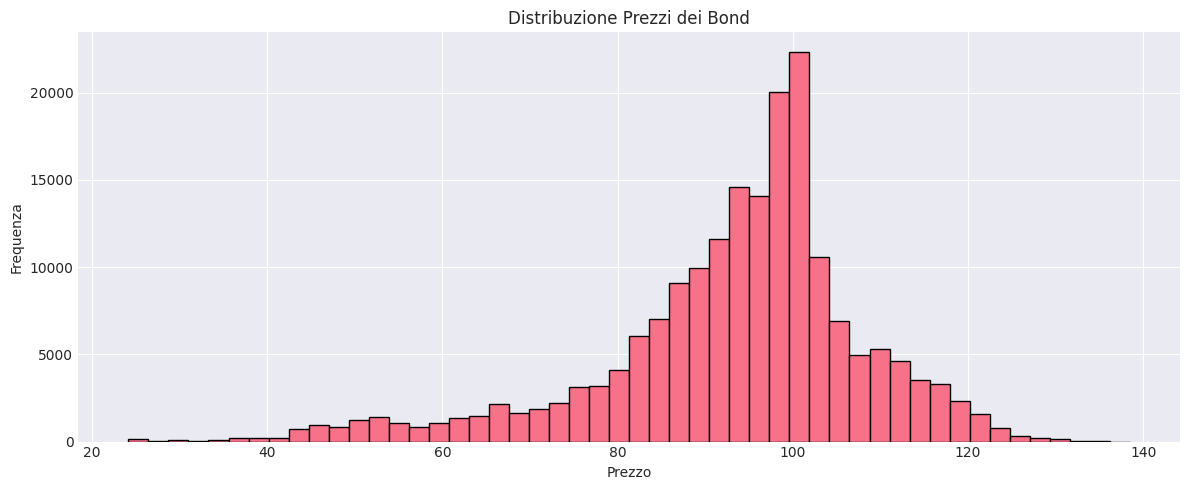

In [59]:
# Analisi dei prezzi
print("--- STATISTICHE PREZZI ---")
print(df_storico_clean['pricevalue'].describe())

# Distribuzione prezzi
fig, ax = plt.subplots(figsize=(12, 5))
df_storico_clean['pricevalue'].hist(bins=50, ax=ax, edgecolor='black')
ax.set_title('Distribuzione Prezzi dei Bond')
ax.set_xlabel('Prezzo')
ax.set_ylabel('Frequenza')
plt.tight_layout()
plt.show()

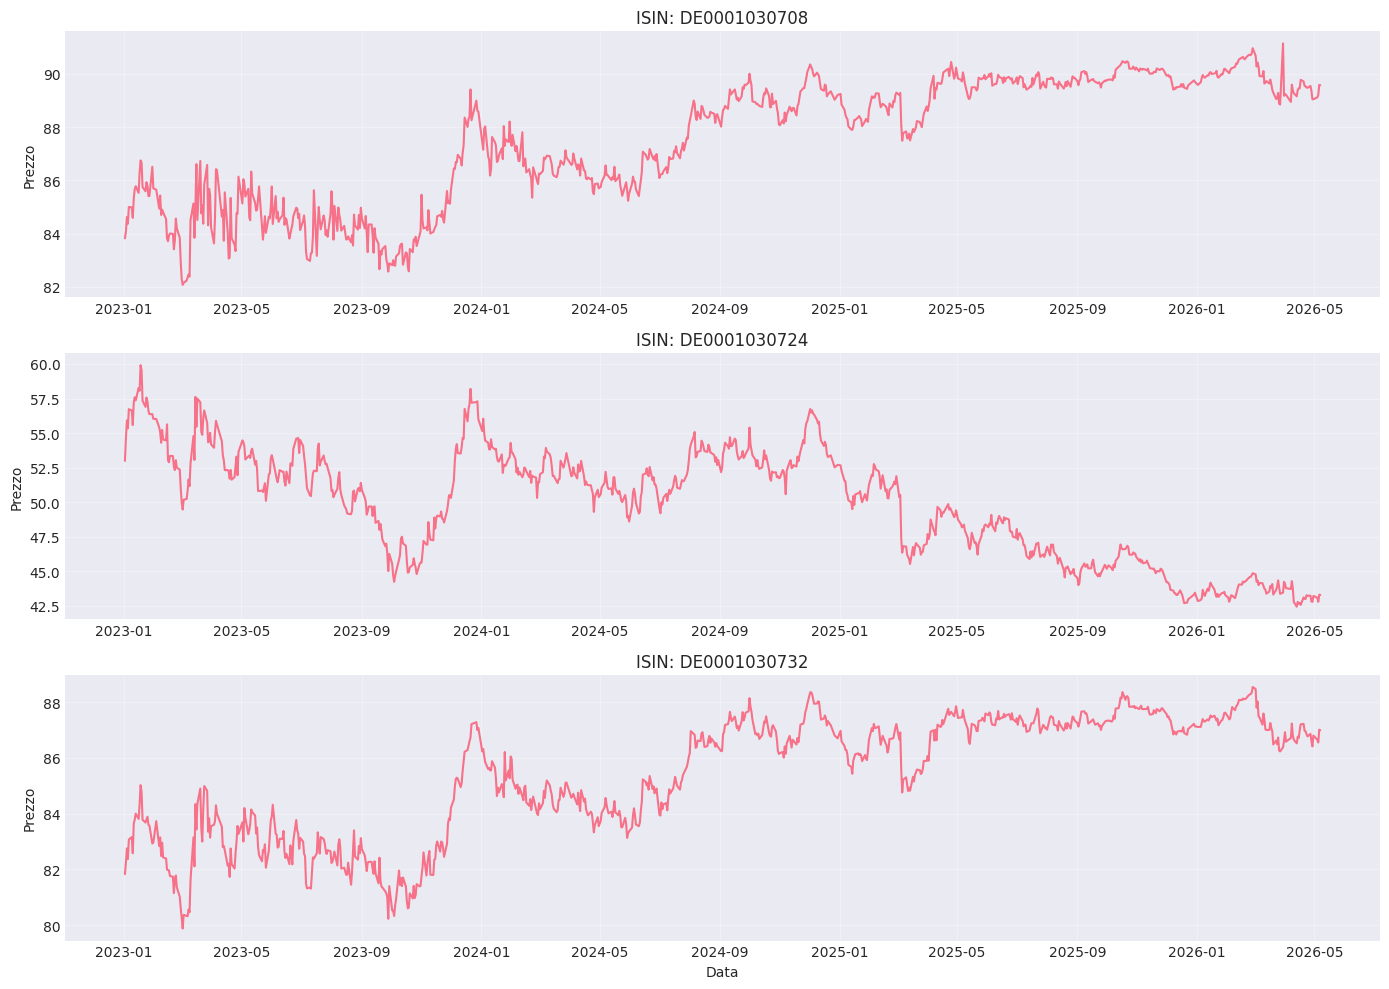

In [60]:
# Time series dei prezzi per un campione di bond
sample_isins = df_storico_clean['isincode'].unique()[:3]
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, isin in enumerate(sample_isins):
    data = df_storico_clean[df_storico_clean['isincode'] == isin].sort_values('referencedate')
    axes[idx].plot(data['referencedate'], data['pricevalue'], linewidth=1.5)
    axes[idx].set_title(f'ISIN: {isin}')
    axes[idx].set_ylabel('Prezzo')
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Data')
plt.tight_layout()
plt.show()

--- STATISTICHE DATI MACRO COMPLETI ---


,ECB_Deposit_Rate,ECB_MRO_Rate,FED_Rate,VIX,ESI_Index,Euribor_3M,Euribor_1Y,HICP_Euroarea,STOXX50,XEON,SEGA
count,9625.000000,9625.000000,9625.000000,9625.000000,9625.000000,9625.000000,9625.000000,9625.000000,6980.000000,6701.000000,5955.000000
mean,1.060036,2.069403,2.049571,19.767188,-10.525631,1.632040,2.972030,76.493887,3522.808560,138.771560,106.820865
std,1.441825,1.865158,2.069635,8.294778,5.413070,1.759720,1.551332,11.429216,867.763280,3.060886,10.820255
min,-0.500000,0.000000,0.040000,9.140000,-27.500000,-0.581957,-0.091882,58.360000,1809.979980,132.399994,85.015770
25%,-0.300000,0.050000,0.150000,13.980000,-13.500000,-0.087619,1.387667,67.470000,2908.110107,136.919006,97.793709
50%,0.500000,1.250000,1.320000,17.740000,-10.900000,1.488591,3.244733,76.740000,3385.250000,138.481293,108.576302
75%,2.250000,4.250000,3.920000,23.170000,-6.100000,3.261261,4.141971,81.670000,4062.512573,139.753006,112.910271
max,4.000000,4.500000,7.030000,82.690000,-0.400000,5.113087,5.698539,103.020000,6173.319824,149.058899,127.180923


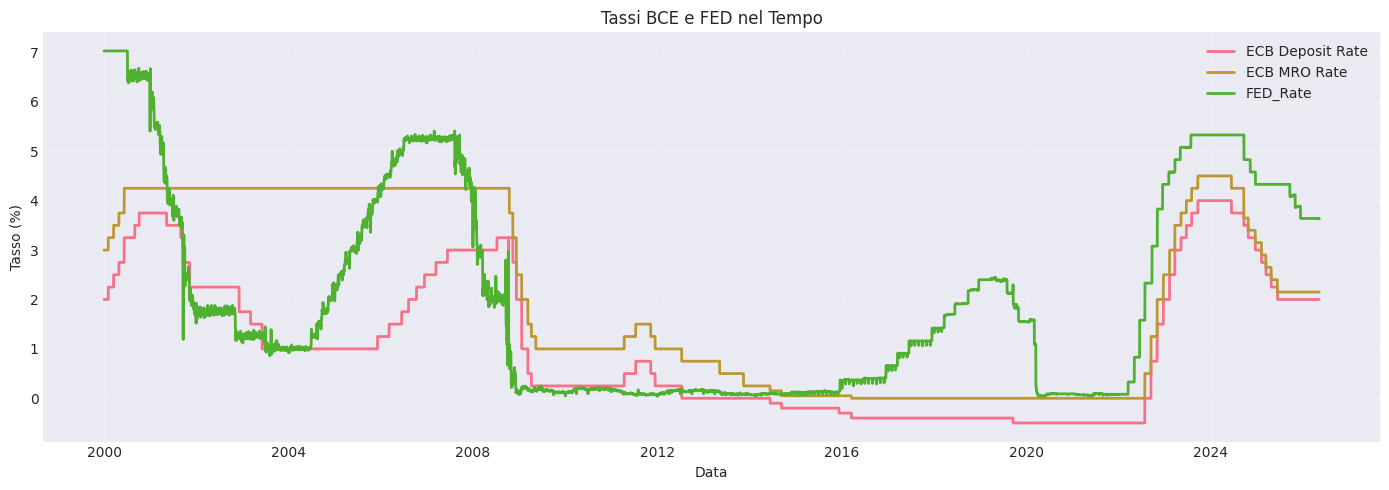

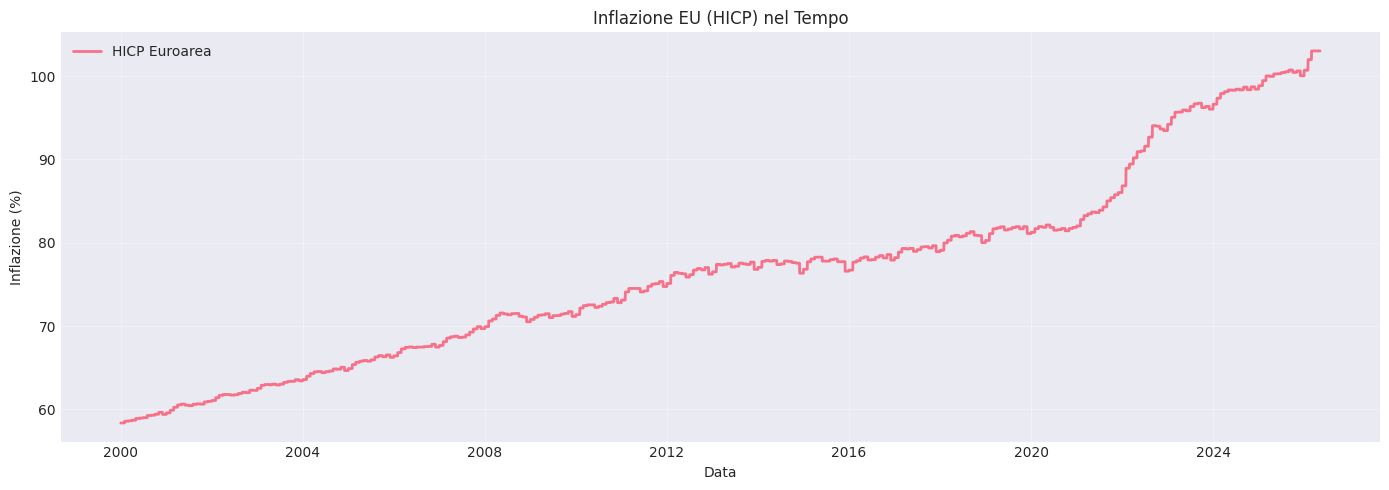

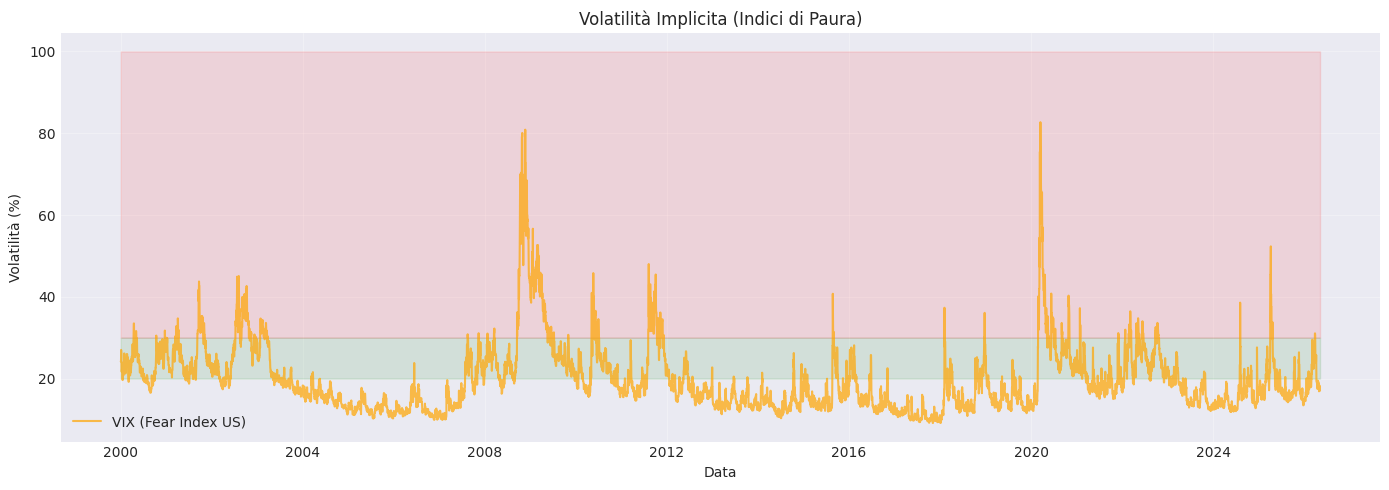

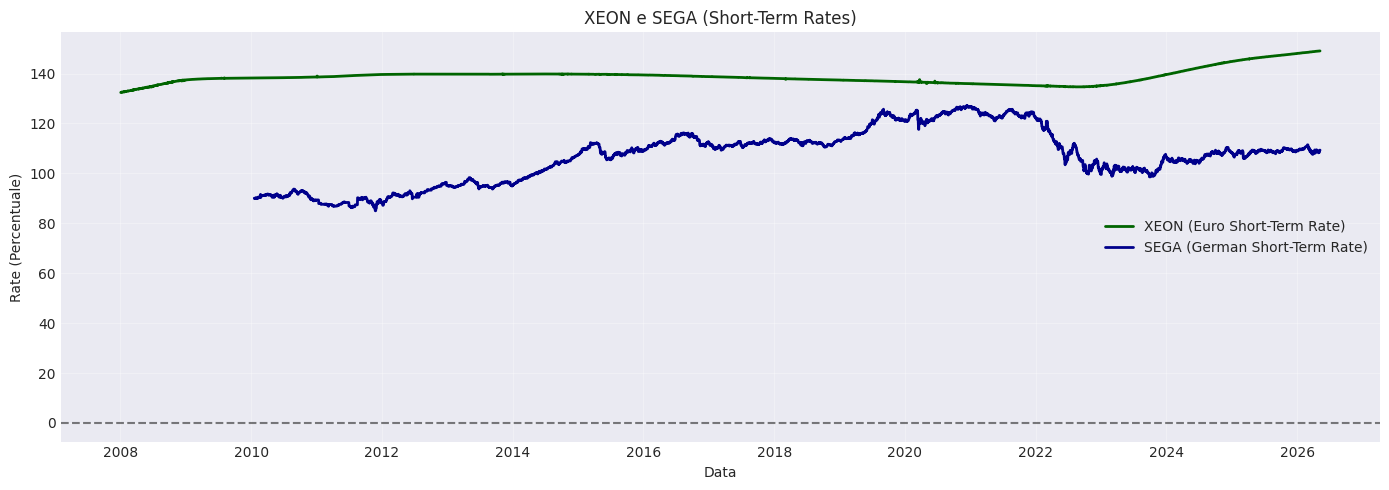

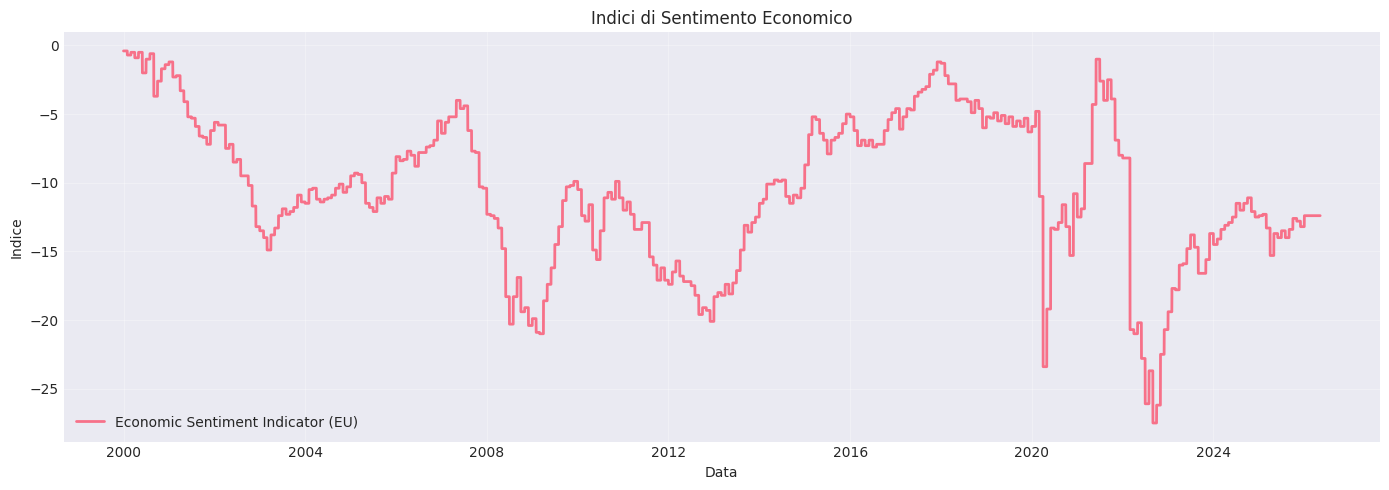

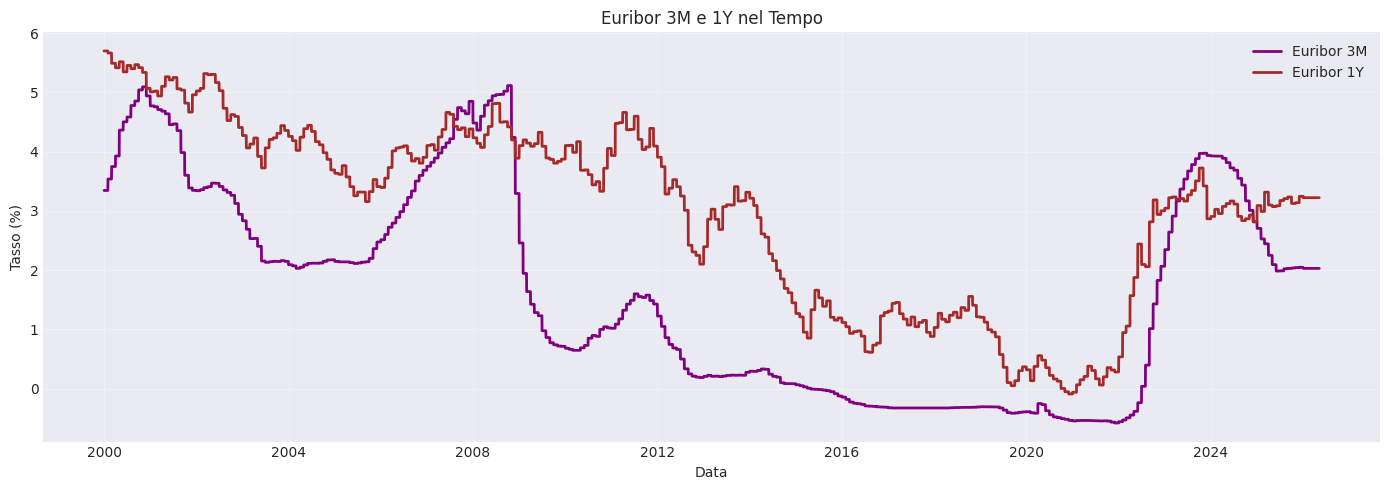

In [61]:
# Analisi dati macro
print("--- STATISTICHE DATI MACRO COMPLETI ---")
display(df_macro.describe())

# 1. Tassi BCE e FED nel tempo
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_macro.index, df_macro['ECB_Deposit_Rate'], label='ECB Deposit Rate', linewidth=2)
if 'ECB_MRO_Rate' in df_macro.columns:
    ax.plot(df_macro.index, df_macro['ECB_MRO_Rate'], label='ECB MRO Rate', linewidth=2)
if 'FED_Rate' in df_macro.columns:
    ax.plot(df_macro.index, df_macro['FED_Rate'], label='FED_Rate', linewidth=2)
ax.set_title('Tassi BCE e FED nel Tempo')
ax.set_ylabel('Tasso (%)')
ax.set_xlabel('Data')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Inflazione (HICP Euroarea)
if 'HICP_Euroarea' in df_macro.columns :
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df_macro.index, df_macro['HICP_Euroarea'], label='HICP Euroarea', linewidth=2)
    ax.set_title('Inflazione EU (HICP) nel Tempo')
    ax.set_ylabel('Inflazione (%)')
    ax.set_xlabel('Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3. Volatilità di mercato (VIX)
if 'VIX' in df_macro.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    if 'VIX' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['VIX'], label='VIX (Fear Index US)', linewidth=1.5, color='orange', alpha=0.7)
    ax.set_title('Volatilità Implicita (Indici di Paura)')
    ax.set_ylabel('Volatilità (%)')
    ax.set_xlabel('Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.fill_between(df_macro.index, 20, 30, alpha=0.1, color='green', label='Normal')
    ax.fill_between(df_macro.index, 30, 100, alpha=0.1, color='red', label='High Fear')
    plt.tight_layout()
    plt.show()

# 4. XEON e SEGA 
if 'XEON' in df_macro.columns or 'SEGA' in df_macro.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    if 'XEON' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['XEON'], label='XEON (Euro Short-Term Rate)', linewidth=2, color='darkgreen')
    if 'SEGA' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['SEGA'], label='SEGA (German Short-Term Rate)', linewidth=2, color='darkblue')
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set_title('XEON e SEGA (Short-Term Rates)')
    ax.set_ylabel('Rate (Percentuale)')
    ax.set_xlabel('Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 5. Indice di sentimento economico (ESI)
if 'ESI_Index' in df_macro.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    if 'ESI_Index' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['ESI_Index'], label='Economic Sentiment Indicator (EU)', linewidth=2)
    ax.set_title('Indici di Sentimento Economico')
    ax.set_ylabel('Indice')
    ax.set_xlabel('Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 6. Euribor 3M e 1Y
if 'Euribor_3M' in df_macro.columns or 'Euribor_1A' in df_macro.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    if 'Euribor_3M' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['Euribor_3M'], label='Euribor 3M', linewidth=2, color='purple')
    if 'Euribor_1Y' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['Euribor_1Y'], label='Euribor 1Y', linewidth=2, color='brown')
    ax.set_title('Euribor 3M e 1Y nel Tempo')
    ax.set_ylabel('Tasso (%)')
    ax.set_xlabel('Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

['ECB_Deposit_Rate', 'ECB_MRO_Rate', 'FED_Rate', 'VIX', 'ESI_Index', 'Euribor_3M', 'Euribor_1Y', 'HICP_Euroarea', 'STOXX50', 'XEON', 'SEGA']


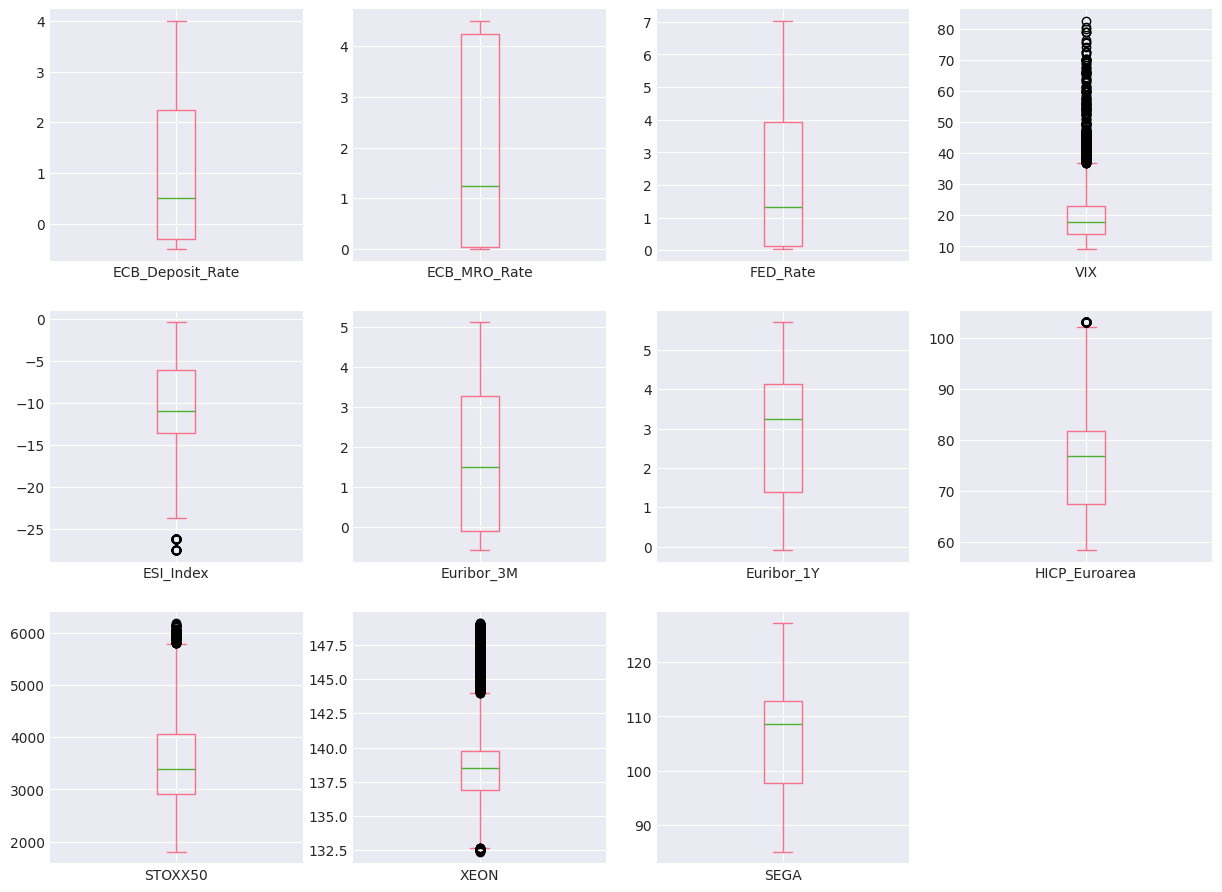

In [62]:
# Valutiamo la distribuzione delle features
feature_cols = [col for col in df_macro.columns if col not in ['isincode', 'description', 'referencedate', 'date', 'redemptiondate', 'endvaluedate']]
print(feature_cols)
df_macro[feature_cols].plot(kind='box', subplots=True, layout=(4,4), figsize=(15,15))
plt.show()

## 1.8 - Save Cleaned Data for Next Stages

In [63]:
# Salva i dataset puliti per il prossimo notebook
df_anagrafica_clean.to_csv('./data/df_anagrafica_clean.csv', index=False)
df_storico_clean.to_csv('./data/df_storico_clean.csv', index=False)
df_macro.to_csv('./data/df_macro.csv')

print("✓ Dataset puliti salvati in ./data/")

✓ Dataset puliti salvati in ./data/


In [64]:
df_storico_clean.shape[0] 

189510